In [68]:
# Imports
from scipy import stats

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Part 1: Data Collection and Preparation

In [1]:
tickers = ["AAPL", "NVDA", "AMZN", "GOOGL", "MSFT"]
start = "2022-01-01"
end = "2026-05-01"
interval = "1d"

In [13]:
# Data downloading and saving
# Close price is used because it is the most widely used in literature.
data = yf.download(tickers=tickers, start=start, end=end, interval=interval, auto_adjust=True)["Close"] # adjusted for splits and dividents
data.head(5)
data.to_csv("data/close_prices_full.csv")

In [15]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1003 entries, 2022-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1003 non-null   float64
 1   AMZN    1003 non-null   float64
 2   GOOGL   1003 non-null   float64
 3   MSFT    1003 non-null   float64
 4   NVDA    1003 non-null   float64
dtypes: float64(5)
memory usage: 47.0 KB


After downloading data, the dataset contains 1003 trading days with no missing values

In [24]:
daily_returns = (data - data.shift(1)) /  data.shift(1)
daily_returns = daily_returns.dropna()

log_daily_returns = np.log(data / data.shift(1))
log_daily_returns = log_daily_returns.dropna()

# Save to csv for later usage
daily_returns.to_csv("data/daily_returns_full.csv")
log_daily_returns.to_csv("data/log_daily_returns_full.csv")

# Part 2: Descriptive Statistics

In [66]:
colors = {
    "AAPL": "#8E8E93",
    "NVDA": "#76B900",
    "AMZN": "#FF9900",
    "GOOGL": "#4285F4",
    "MSFT": "#F25022"
}

rolling_window = 25 # Month has 25 trading days

Plot 1: Price and its moving average

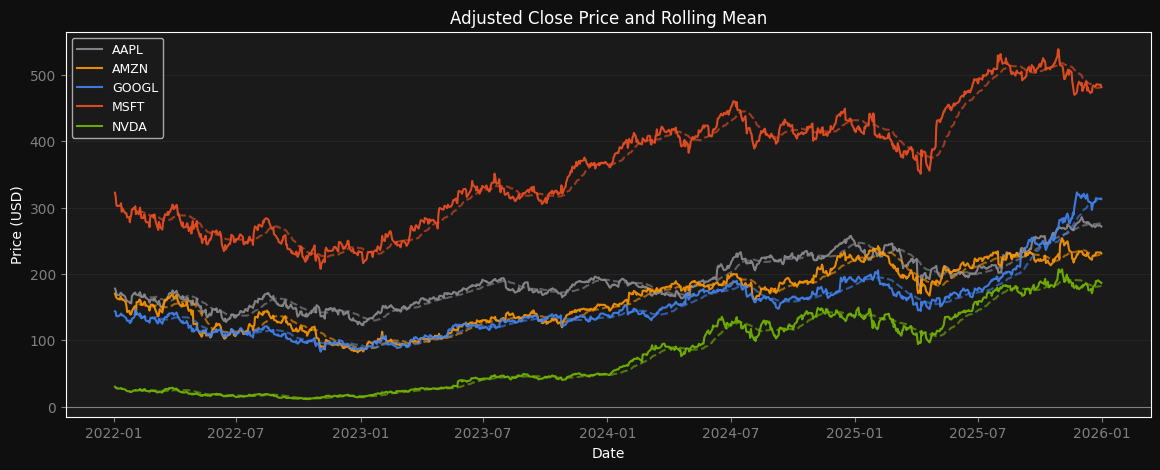

In [67]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")
for ticker in data.columns:
    ax.plot(data.index, data[ticker], color=colors[ticker], label=ticker, alpha=0.9)
    ax.plot(data.index, data[ticker].rolling(rolling_window).mean(), color=colors[ticker], linestyle="--", alpha=0.6)

ax.axhline(0, color="gray", linewidth=0.8)
ax.tick_params(colors="gray")
ax.set_title("Adjusted Close Price and Rolling Mean", color="white")
ax.set_ylabel("Price (USD)")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
ax.set_xlabel("Date")
ax.legend(facecolor="#1A1A1A", labelcolor="white", framealpha=0.8, fontsize=9)
plt.savefig("plots/price_rolling_mean.png",facecolor=fig.get_facecolor())

Plot 2: Daily returns

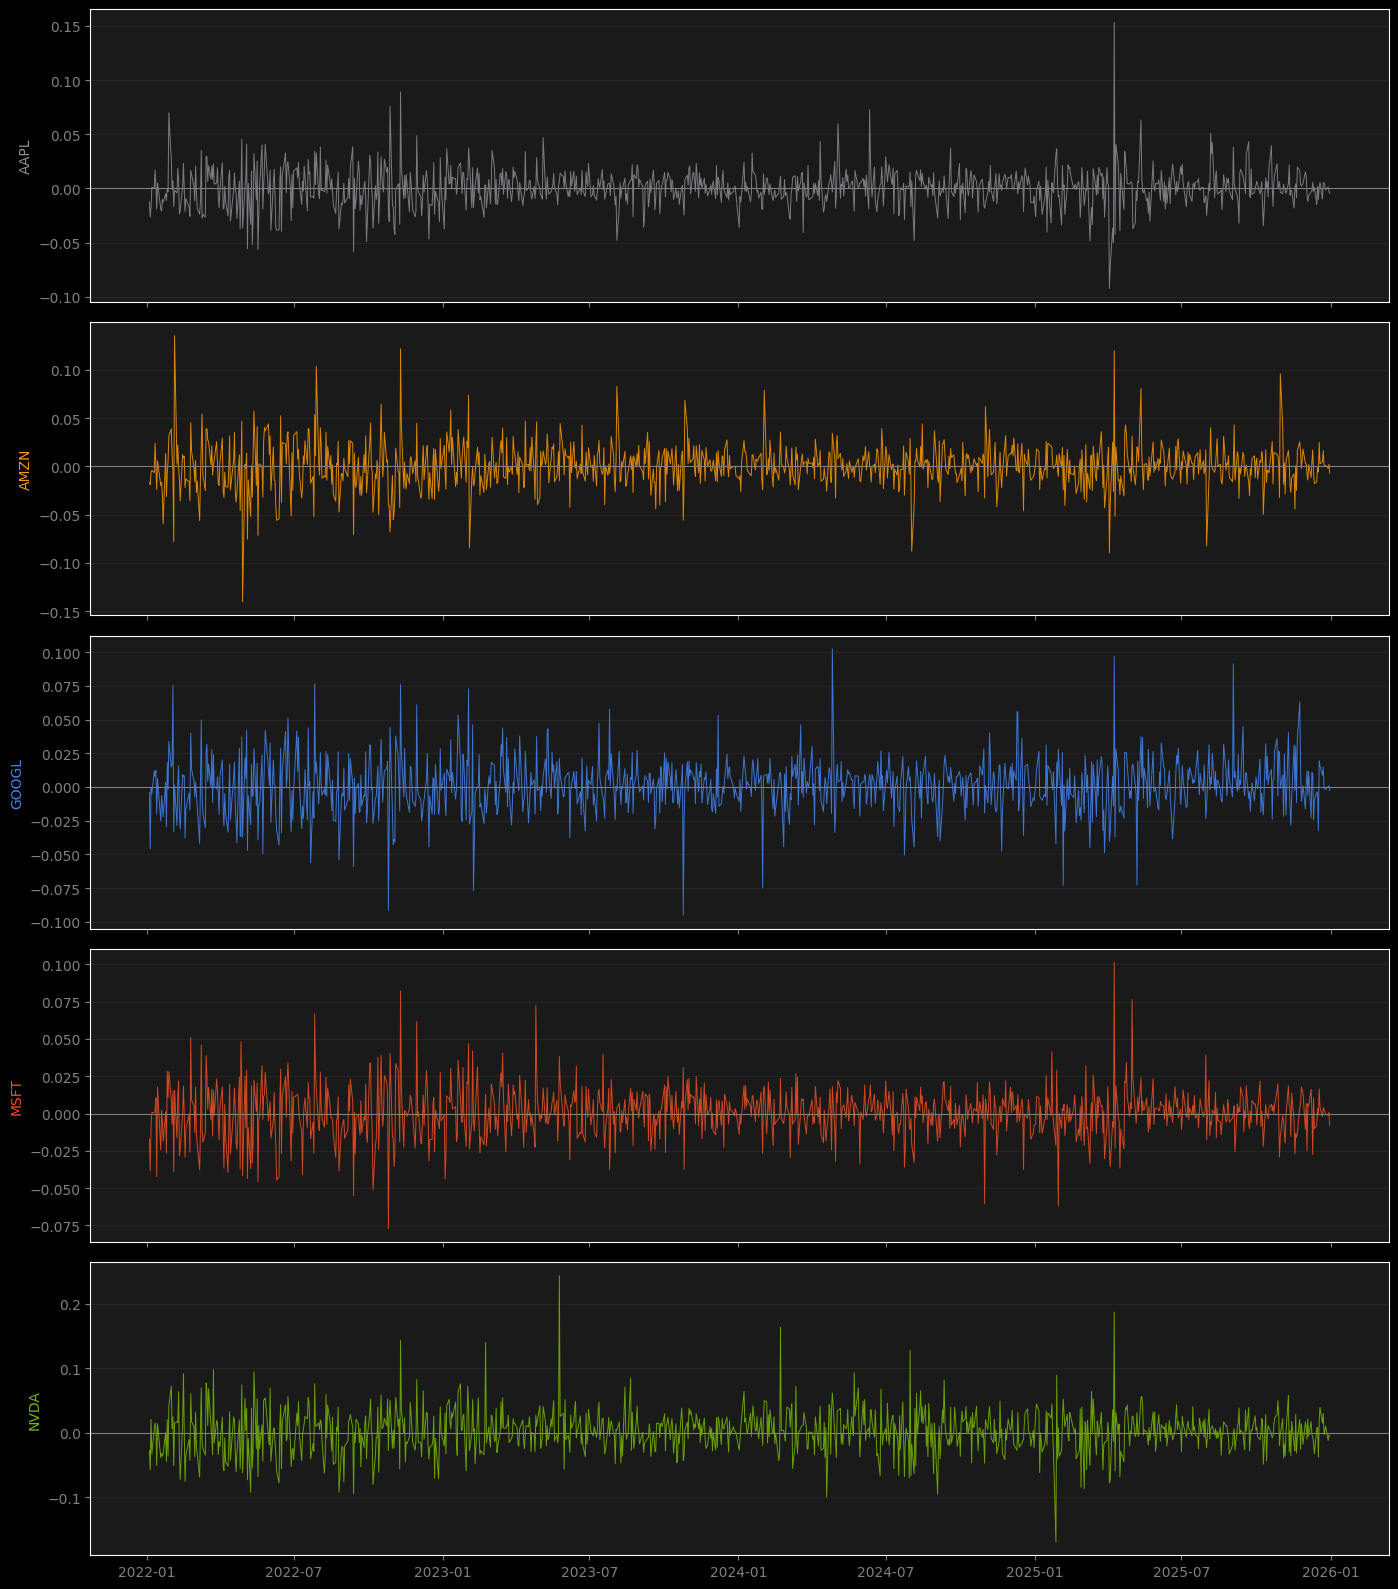

In [51]:
ig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True) # We plot with subplots, as all are centered near 0 and it is not possible to distinguish in one plot
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(daily_returns.index, daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/daily_returns.png",facecolor=fig.get_facecolor())
plt.show()


Plot 3: Log daily returns

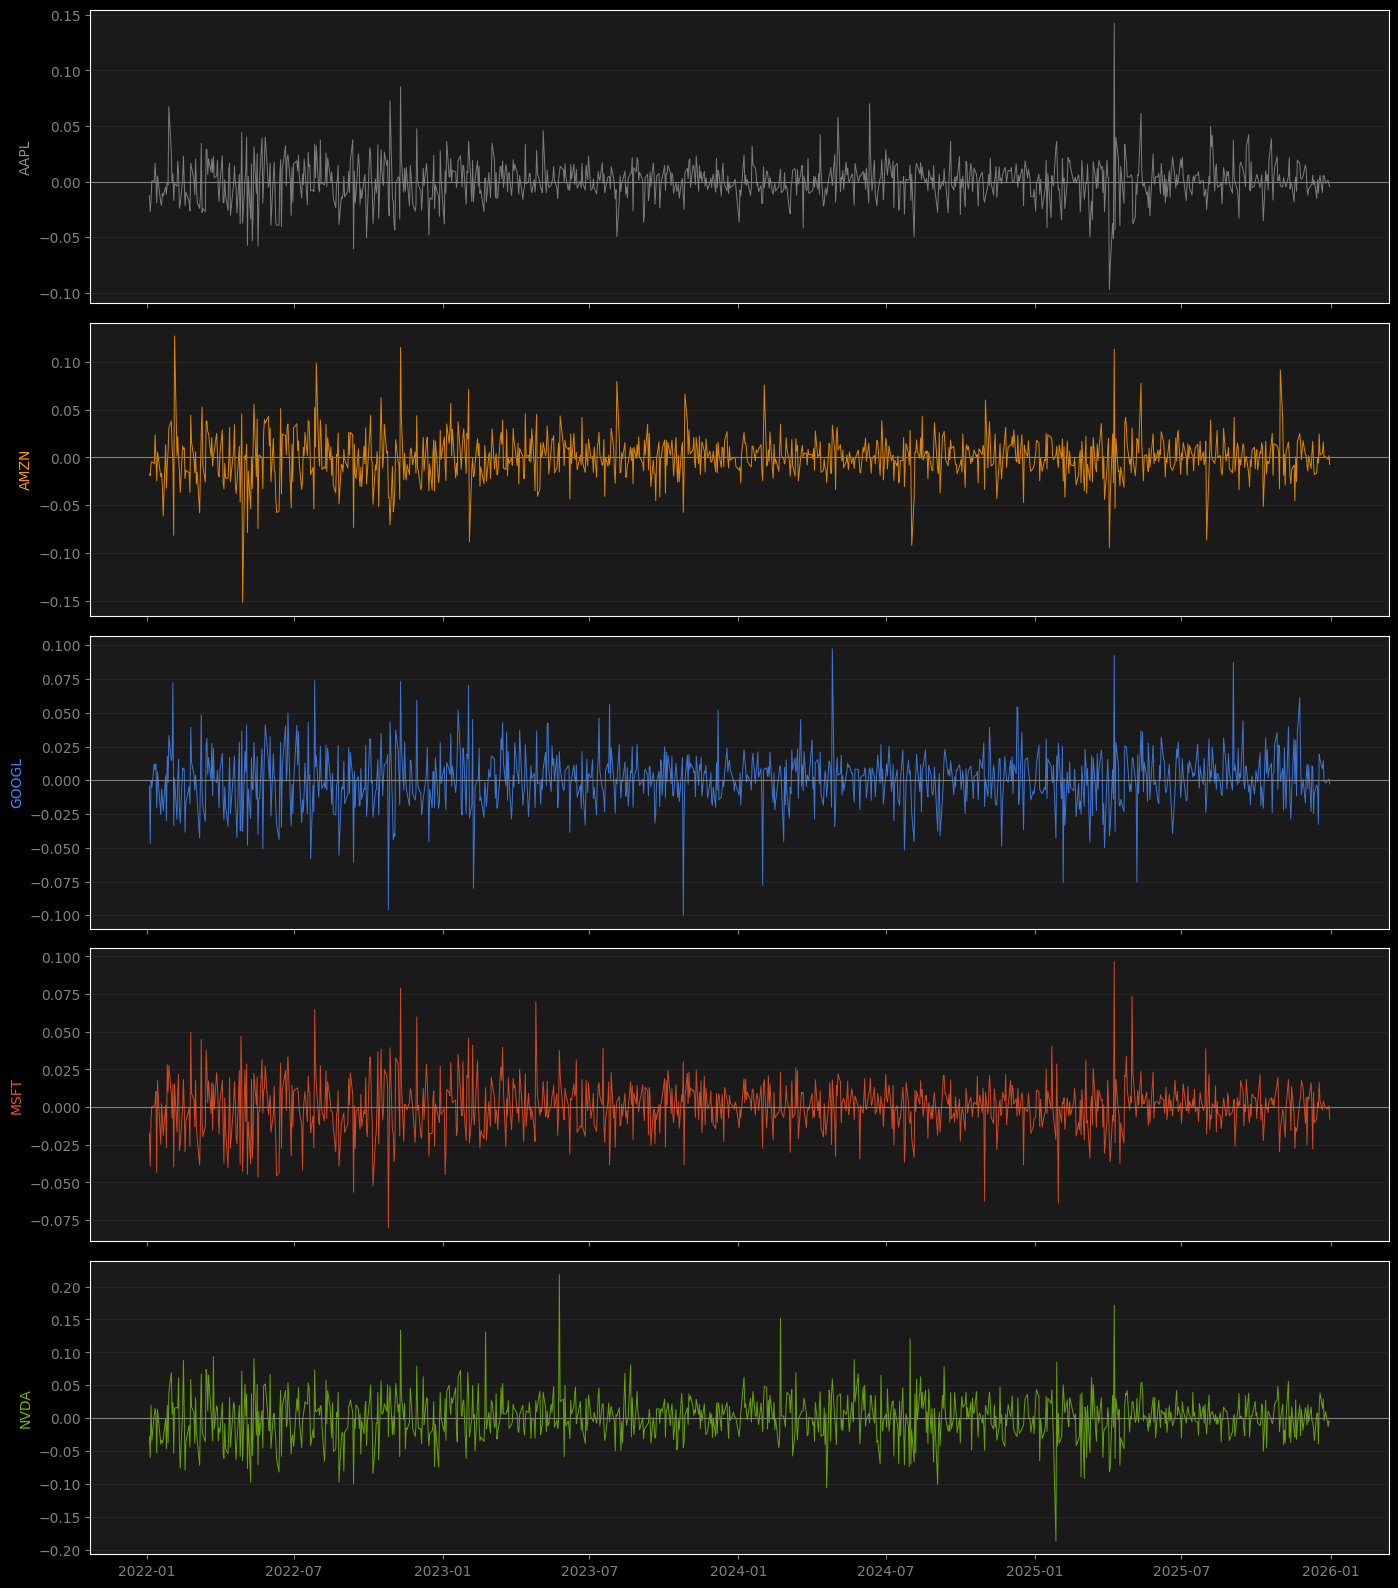

In [53]:
ig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Log Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, log_daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(log_daily_returns.index, log_daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/log_daily_returns.png",facecolor=fig.get_facecolor())
plt.show()

#TODO Add conclusions

In [71]:
# Statistics for daily returns

summary_daily = daily_returns.describe().T
summary_daily["skewness"] = daily_returns.skew()
summary_daily["kurtosis"] = daily_returns.kurt()

summary_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
AAPL,1002.0,0.000582,0.017969,-0.092456,-0.008163,0.000847,0.009408,0.153289,0.550669,7.414533
AMZN,1002.0,0.000579,0.023546,-0.140494,-0.012153,0.000418,0.013622,0.135359,0.167900,4.764001
GOOGL,1002.0,0.000987,0.020567,-0.095094,-0.010752,0.001343,0.011904,0.102244,0.084321,2.955452
MSFT,1002.0,0.000542,0.016868,-0.077156,-0.007981,0.000771,0.009777,0.101337,0.247241,3.349134
NVDA,1002.0,0.002393,0.033950,-0.169682,-0.017373,0.002990,0.021394,0.243696,0.539854,4.755521


In [72]:
# Statistics for daily log returns

summary_log_daily = log_daily_returns.describe().T
summary_log_daily["skewness"] = log_daily_returns.skew()
summary_log_daily["kurtosis"] = log_daily_returns.kurt()

summary_log_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
AAPL,1002.0,0.000421,0.017895,-0.097013,-0.008197,0.000847,0.009364,0.142617,0.321891,6.305108
AMZN,1002.0,0.000303,0.023530,-0.151398,-0.012227,0.000418,0.013530,0.126949,-0.068593,4.749779
GOOGL,1002.0,0.000776,0.020551,-0.099924,-0.010810,0.001343,0.011834,0.097348,-0.067239,2.934981
MSFT,1002.0,0.000400,0.016836,-0.080295,-0.008013,0.000771,0.009730,0.096525,0.117142,3.105281
NVDA,1002.0,0.001822,0.033682,-0.185946,-0.017526,0.002986,0.021169,0.218088,0.236265,3.842683


In [ ]:
# TODO Add conclusion